### RNN (Recurent Neural Network) : 단기메모리
- 순서가 중요, 이전사건이 다음사건에 영향을 미치는 구조
- 순서가 중요한 데이터를 --> 시계열
- 자연어, 주식, 날씨, 실시간 센서데이터
- 단점 : 장기메모리에 약함
- 개선 : LSTM(RNN에 비해서 오래 기억하지만 그래도 희석됨)
- 트랜스포머 : 집중해야할것 즉 기억해야할 중요내용만 저장(어텐션), 마스킹
### MLP
- 모든 입력이 독립적, 자연어는 순서가 중요(단어의 순서)

In [38]:
from nltk.corpus import movie_reviews
reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]
categories = [movie_reviews.categories(fileid)[0] for fileid in movie_reviews.fileids()]

In [39]:
len(reviews), len(reviews[0]), set(categories)

(2000, 4043, {'neg', 'pos'})

In [40]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
np.random.seed(42)
tf.random.set_seed(42)

In [41]:
# 사용할 단어수
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='UNK')  #빈도가 높은 10000개의 단어를 선택
tokenizer.fit_on_texts(reviews)  # 단어 인덱스 구축
x = tokenizer.texts_to_sequences(reviews)  # 인덱스를 기반으로 원래 문장을 숫자로 변환(벡터화, 개별적으로 즉 길이는 서로 다름)

In [42]:
len(x[0]), len(x[1]), x[0][:10]

(710, 240, [98, 77, 949, 4622, 131, 6, 3, 2016, 789, 3764])

In [43]:
# 학습을 위해서는 모든 문장의 길이가 같아야 함 - > 패딩  짧으면 채우고 길면 자르고
from tensorflow.keras.preprocessing.sequence import pad_sequences
maxlen = 500
x = pad_sequences(x,maxlen=maxlen,truncating='pre' )  # 앞을 자름

In [44]:
len(x[0]), len(x[1]), x[0][:10]

(500,
 500,
 array([ 911,  115,   53,   21, 5278,    5, 1387,  172,    9,  633],
       dtype=int32))

In [45]:
label_dict = {'pos' : 1, 'neg' : 0}
y = np.array([label_dict[c] for c in categories])
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [47]:
x_train.shape

(1600, 500)

In [48]:
# 일반신경망으로 분리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,Embedding, Dropout

model = Sequential([
    Embedding(max_words,32,input_length=maxlen),    # 1600, 500 --> 1600, 500, 32
    Dropout(0.5),
    Flatten(),
    Dense(1,activation='sigmoid')  # 확률 분포
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10,validation_split=0.2)

Epoch 1/10


c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.5211 - loss: 0.6925 - val_acc: 0.5375 - val_loss: 0.6930
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8727 - loss: 0.6215 - val_acc: 0.5906 - val_loss: 0.6888
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9531 - loss: 0.5342 - val_acc: 0.6062 - val_loss: 0.6798
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9836 - loss: 0.4155 - val_acc: 0.6219 - val_loss: 0.6696
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9937 - loss: 0.2885 - val_acc: 0.6344 - val_loss: 0.6571
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9969 - loss: 0.1865 - val_acc: 0.6375 - val_loss: 0.6425
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9984 - loss: 0.1235 - val_acc: 0.6562 - val_loss: 0.6340
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9984 - loss: 0.0832 - val_acc: 0.6594 - val_loss: 0.6294
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9992 - loss: 0.0607 - va

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


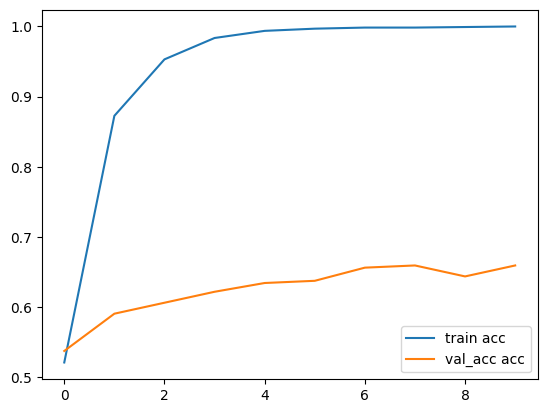

In [49]:
import matplotlib.pyplot as plt
print(history.history.keys())
plt.plot(history.history['acc'], label = 'train acc')
plt.plot(history.history['val_acc'], label = 'val_acc acc')
plt.legend()
plt.show()

In [50]:
model.evaluate(x_test,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6725 - loss: 0.6183 


[0.6183186173439026, 0.6725000143051147]

In [51]:
from tensorflow.keras.layers import SimpleRNN
model = Sequential([
    Embedding(max_words,32,input_length=maxlen),    # 1600, 500 --> 1600, 500, 32
    SimpleRNN(32),    # 1600, 32   단순선형모델에 사용되는 Flatten 대신    
    Dropout(0.5),
    Dense(64,activation='relu'),  # 확률 분포
    Dropout(0.5),
    Dense(1,activation='sigmoid')  # 확률 분포
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10,validation_split=0.2)
model.evaluate(x_test,y_test)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.4961 - loss: 0.7010 - val_acc: 0.5000 - val_loss: 0.6960
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5992 - loss: 0.6761 - val_acc: 0.5094 - val_loss: 0.6940
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.6180 - loss: 0.6517 - val_acc: 0.4969 - val_loss: 0.6937
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.7289 - loss: 0.5906 - val_acc: 0.5125 - val_loss: 0.6987
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.8766 - loss: 0.4099 - val_acc: 0.5125 - val_loss: 0.7813
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9680 - loss: 0.1834 - val_acc: 0.5094 - val_loss: 0.9265
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9867 - loss: 0.0794 - val_acc: 0.5312 - val_loss: 1.0419
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9961 - loss: 0.0386 - val_acc: 0.5312 - val_loss: 1.1196
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9977

[1.3439985513687134, 0.5224999785423279]

In [52]:
np.astype(model.predict(x_test).reshape(-1,) > 0.5, int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,

In [53]:
sum(np.astype(model.predict(x_test).reshape(-1,) > 0.5, int) == y_test) / len(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


np.float64(0.5225)